# V3 — a population of genuine $D$-dimensional vector-valued neurons on SHD

## The hypothesis

A neuron's internal computational state **is** a high-dimensional vector, not a
scalar that is embedded afterwards.  Neuron $i$ owns

$$\mathbf z_i(t) \in \mathbb R^{D}, \qquad D = 1000,$$

and the $D$ dimensions take part directly in the neuron's own recurrent
dynamics, in its interaction with the other neurons, and in the generation of
its spike output.  The population state is $Z(t)\in\mathbb R^{N\times D}$ with
$N$ configurable.

## What this notebook is *not*

* not a post-hoc encoder: there is no `scalar neuron -> simulate -> features -> PCA`
  pipeline anywhere, and no `nn.Linear` that embeds a scalar neuron into a vector;
* not a fixed dynamical system with a trained readout (that was the limitation of
  the previous Brian 2 experiment) — **every** parameter that shapes the vector
  dynamics is trained end-to-end;
* not a representation-quality study.  PCA / UMAP / manifold geometry / cosine
  similarity are not computed.  The single number that matters is the accuracy on
  the official SHD test set.

## The question

> **How much of the official SHD test set can a population of $D=1000$
> vector-valued neurons classify correctly?**

A scalar-state population ($D=1$, same $N$, same data, same training procedure,
same readout) is trained as the reference point.

## Layout

| § | Section |
|---|---------|
| 1 | Environment |
| 2 | Configuration |
| 3 | Load SHD |
| 4 | Data inspection / sanity check |
| 5 | Define the vector neuron |
| 6 | Define the population |
| 7 | Define the classifier |
| 8 | Training |
| 9 | Training visualisations |
| 10 | Save checkpoint |
| 11 | Test (official SHD test set) |
| 12 | Test visualisations |
| 13 | Scalar baseline |
| 14 | Final comparison |
| 15 | Results / notes |

Everything is imported from the small `v3` package next to this notebook; the
notebook contains no scientific logic of its own, so the command-line runner
`V3/run_experiment.py` produces byte-identical results for the same configuration.

Set the environment variable `V3_QUICK=1` before launching the kernel to run a
minutes-long smoke of the *identical* code path.

## 1. Environment

In [1]:
import os
import sys
import time
from pathlib import Path


# locate the V3 folder (works whether the kernel starts in the repo root or in V3/)
def find_v3_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "v3" / "model.py").exists() and (cand / "configs" / "v3_default.yaml").exists():
            return cand
    raise RuntimeError(f"could not locate the V3 folder from {start}")


V3_ROOT = find_v3_root(Path(os.getcwd()))
sys.path.insert(0, str(V3_ROOT))

import numpy as np
import torch
from IPython.display import Image, display

from v3.config import V3Config, describe, parameter_groups
from v3.data import SHDEventStore, make_split, official_test_split
from v3.experiment import resolve_device, test_variant, train_variant, variant_dirs
from v3.model import VectorNeuronPopulation, surrogate_spike
from v3.train import save_json

DEVICE = resolve_device(V3Config())
print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}")
print(f"V3 root     {V3_ROOT}")
print(f"device      {DEVICE}" + (f"  ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else ""))
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"gpu memory  {props.total_memory / 2**30:.2f} GiB, compute capability {props.major}.{props.minor}")

python      3.11.14
torch       2.14.0+cu126
V3 root     C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\V3
device      cuda  (NVIDIA GeForce RTX 3060 Laptop GPU)
gpu memory  6.00 GiB, compute capability 8.6


## 2. Configuration

One YAML file holds every experimental parameter; nothing is hard-coded in the
model, the data loader or this notebook.  `D` and `N` are ordinary keys.

In [2]:
import json as _json

CONFIG_FILE = V3_ROOT / "configs" / "v3_default.yaml"

# Set V3_QUICK=1 in the environment to run a minutes-long smoke of the same
# code path (small N, small D, few samples, few epochs).  V3_OVERRIDES accepts a
# JSON object of configuration overrides, e.g.
#   V3_OVERRIDES='{"epochs": 2, "max_train_samples": 512}'
QUICK = bool(int(os.environ.get("V3_QUICK", "0")))
QUICK_OVERRIDES = dict(n_neurons=16, state_dim=64, mix_rank=8, n_bins=60,
                       batch_size=16, epochs=20, max_train_samples=256,
                       val_fraction=0.15, tag="v3_quick_smoke")
OVERRIDES: dict = _json.loads(os.environ.get("V3_OVERRIDES", "{}"))

cfg = V3Config.from_yaml(CONFIG_FILE).with_overrides(**OVERRIDES)
if QUICK:
    cfg = cfg.with_overrides(**QUICK_OVERRIDES)
cfg = cfg.resolved()

print(f"config file : {CONFIG_FILE}")
print(f"mode        : {'QUICK SMOKE' if QUICK else 'PRIMARY'}")
print(f"overrides   : {OVERRIDES if OVERRIDES else '{}  (none)'}")
print(f"device/dtype: {cfg.device} / {cfg.dtype}")
print(f"tag         : {cfg.tag}")
print(f"N (neurons) : {cfg.n_neurons}")
print(f"D (state dim): {cfg.state_dim}")
print(f"T x bin     : {cfg.n_bins} x {cfg.bin_ms:g} ms = {cfg.duration_s:g} s")
print(f"batch/epochs: {cfg.batch_size} / {cfg.epochs}")
print(f"lr / optim  : {cfg.learning_rate:g} / {cfg.optimizer} ({cfg.lr_schedule})")
print(f"tau (leak)  : {cfg.tau_ms:g} ms   -> alpha = dt/tau = {cfg.alpha:g}")

config file : C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\V3\configs\v3_default.yaml
mode        : PRIMARY
overrides   : {}  (none)
device/dtype: cuda / float16
tag         : v3_vector_d1000
N (neurons) : 64
D (state dim): 1000
T x bin     : 250 x 4 ms = 1 s
batch/epochs: 128 / 20
lr / optim  : 0.001 / adam (cosine)
tau (leak)  : 20 ms   -> alpha = dt/tau = 0.2


In [3]:
groups = parameter_groups(cfg)
w = max(len(k) for k in groups)
print(f"{'parameter'.ljust(w)}  {'count':>12}")
print("-" * (w + 14))
for k, v in groups.items():
    print(f"{k.ljust(w)}  {v:>12,}")

parameter         count
--------------------
w_in         700,000
w_down        64,000
w_up          64,000
w_emit     1,000,000
w_rec          4,096
gate          64,000
bias          64,000
w_out         64,000
theta             64
w_cls          1,280
total      2,025,440


## 3. Load SHD

The official event-based files are used directly.  SHD samples are *ragged*
`(time, channel)` event lists; they are binned onto a `T x C` grid (one
dynamical step per bin) and never collapsed into a static feature vector.

The validation split is carved out of the official **training** file only.  The
official **test** file is not opened until §11.

In [4]:
store = SHDEventStore(cfg.path(cfg.train_h5), cfg)
fit_split, val_split = make_split(store, cfg)
for s in (fit_split, val_split):
    s_ = s.summary()
    print(f"{s_['name']:>4s}: n={s_['n']:5d}  classes={s_['classes_present']:2d}  speakers={s_['speakers']}")
print(f"\ntrain file  : {cfg.path(cfg.train_h5)}")
print(f"test file   : {cfg.path(cfg.test_h5)}  (untouched until section 11)")

 fit: n= 7340  classes=20  speakers=[0, 1, 2, 3, 6, 7, 8, 9, 10, 11]
 val: n=  816  classes=20  speakers=[0, 1, 2, 3, 6, 7, 8, 9, 10, 11]

train file  : C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\data\shd_train.h5
test file   : C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\data\shd_test.h5  (untouched until section 11)


## 4. Data inspection / sanity check

In [5]:
stats = store.stats(sample=2000)
for k, v in stats.items():
    if k not in ("labels", "speakers"):
        print(f"{k:24s} {v}")
print(f"{'labels (train)':24s} {stats['labels']}")
print(f"{'speakers (train)':24s} {stats['speakers']}")

xb = store.batch(fit_split.indices[:8])
binary_ok = bool(set(np.unique(xb).tolist()) <= {0.0, 1.0})
print(f"\ntoy batch        : {xb.shape} {xb.dtype}  (B, T, C)")
print(f"value range      : [{xb.min():g}, {xb.max():g}]   binary encoding: {binary_ok}")
print(f"active-cell frac : {xb.mean():.4f} per (T, C) cell")
print("events per sample in this batch:", xb.sum(axis=(1, 2)).astype(int).tolist())

file                     C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\data\shd_train.h5
n_samples                8156
n_inputs                 700
n_bins                   250
bin_ms                   4.0
window_ms                1000.0
events_sampled           15515271
events_inside_window     15513298
event_clip_fraction      0.00012716503630516574
occupied_cells_mean      7592.5055
input_density            0.04338574571428572
labels (train)           [406, 401, 404, 407, 393, 399, 400, 400, 395, 406, 411, 412, 412, 413, 418, 421, 415, 412, 410, 421]
speakers (train)         [0, 1, 2, 3, 6, 7, 8, 9, 10, 11]

toy batch        : (8, 250, 700) float32  (B, T, C)
value range      : [0, 1]   binary encoding: True
active-cell frac : 0.0434 per (T, C) cell
events per sample in this batch: [4183, 12059, 4753, 10081, 10396, 7652, 6024, 5616]


## 5. Define the vector neuron

One neuron owns $\mathbf z_i(t)\in\mathbb R^D$ and a spike output $s_i(t)$.  With
$\mathbf a(t) = \mathbf x(t)W_{in}\in\mathbb R^{D}$ the shared input projection,
$\mathbf h(t)$ the population signal and $c_i(t)$ the scalar recurrent drive:

$$
\begin{aligned}
o_i(t)   &= \langle \mathbf z_i(t), \mathbf w^{out}_i\rangle + \theta_i,
 &\quad s_i(t) = \mathbf 1[o_i(t) > 0] \\[2pt]
\mathbf d_i(t) &= \mathbf g_i \odot \mathbf a(t) \;+\; c_i(t)\,\mathbf h(t) \;+\; \mathbf b_i
 &\quad (\text{vector drive})\\[2pt]
\mathbf z_i(t{+}1) &= (1-\alpha)\,\mathbf z_i(t) + \alpha\,
     \tanh\!\big(\mathbf m_i(t) + \mathbf d_i(t)\big),
 &\quad \alpha = \Delta t/\tau \\[2pt]
\mathbf m_i(t) &= \big(\mathbf z_i(t)W_{down}\big)W_{up}
 &\quad (\text{shared rank-}R\text{ coupling of the }D\text{ coordinates})
\end{aligned}
$$

* $\tanh$ bounds the state ($|\mathbf z_i|\le 1$), which is what makes `fp16` safe.
  It is *not* part of the hypothesis: it is applied to the vector
  $\mathbf m_i+\mathbf d_i$, so it does not decouple the $D$ coordinates.
* the coupling between the $D$ coordinates comes from $W_{down}W_{up}$ (rank $R$,
  shared), from the shared input projection $W_{in}$ and from the population
  signal — not from the pointwise nonlinearity.

## 6. Define the population

$$
\mathbf h(t) = \tfrac{1}{\sqrt N}\Big(\sum_j s_j(t)\,\mathbf z_j(t)\Big)W_{emit},
\qquad
c_i(t) = \sum_j W_{rec}[j,i]\,s_j(t)
$$

Neuron $j$'s spike emits **its own $D$-dimensional state**, so every other
neuron's vector dynamics is driven by it.  The $1/\sqrt N$ is the standard
mean-field scaling: a sum of $N$ unit contributions has magnitude $\sim\sqrt N$,
so the population signal stays $O(1)$ and the drive does not grow with $N$.

## 7. Define the classifier

$$
\text{logits} = \Big(\sum_t \mathbf s(t)\Big) W_{cls}\in\mathbb R^{20}
$$

A spike-count readout (the standard SHD readout).  Spikes are trained through a
fast-sigmoid surrogate gradient.

In [6]:
device = resolve_device(cfg)
model = VectorNeuronPopulation(cfg).to(device)

rows = sorted(model.param_groups().items(), key=lambda kv: -kv[1])
w = max(len(k) for k, _ in rows)
print(f"{'tensor'.ljust(w)}  {'shape':>18}  {'params':>12}  trainable")
print("-" * (w + 48))
for name, p in model.named_parameters():
    shape = "x".join(str(s) for s in tuple(p.shape))
    print(f"{name.ljust(w)}  {shape:>18}  {p.numel():>12,}  {p.requires_grad}")
print("-" * (w + 48))
print(f"{'TOTAL'.ljust(w)}  {'':>18}  {model.n_parameters():>12,}")

tensor               shape        params  trainable
------------------------------------------------------
w_in              700x1000       700,000  True
w_down             1000x64        64,000  True
w_up               64x1000        64,000  True
w_emit           1000x1000     1,000,000  True
w_rec                64x64         4,096  True
gate               64x1000        64,000  True
bias               64x1000        64,000  True
w_out              64x1000        64,000  True
theta                   64            64  True
w_cls                64x20         1,280  True
------------------------------------------------------
TOTAL                          2,025,440


In [7]:
# Spike thresholds are initialised so that every neuron starts near the target
# rate (they remain trainable).  This is an initialisation device only.
probe = store.batch(fit_split.indices[: min(cfg.batch_size, len(fit_split))])
model.calibrate_threshold(torch.from_numpy(probe).to(device, non_blocking=True),
                          target_rate_hz=cfg.rate_target_hz)
with torch.no_grad():
    _, sp = model(torch.from_numpy(probe).to(device, non_blocking=True))
print(f"target rate           : {cfg.rate_target_hz:g} Hz")
print(f"rate after calibration: {float(model.rate_hz(sp).mean()):.2f} Hz  "
      f"(min {float(model.rate_hz(sp).min()):.2f}, max {float(model.rate_hz(sp).max()):.2f})")

target rate           : 10 Hz
rate after calibration: 10.53 Hz  (min 9.03, max 12.93)


In [8]:
# ---- structural check: the state really is (B, N, D) and really is fp16 ----
# Pure sanity check, so it runs under no_grad and frees its tensors: at D=1000 an
# un-checkpointed 250-step forward *with* gradients builds an ~8 GiB graph, which
# exceeds this 6 GiB device and would leave the notebook paging for the whole
# session (measured: 333 s/batch instead of 2.2 s/batch).
with torch.no_grad():
    x = torch.from_numpy(probe).to(device, non_blocking=True)
    z0 = model.init_state(x.shape[0], device)
    a = (x.reshape(-1, cfg.n_inputs).to(cfg.torch_dtype) @ model.w_in.to(cfg.torch_dtype)
         ).reshape(x.shape[0], cfg.n_bins, cfg.state_dim)
    z1, s1, p1 = model._segment(z0, a)

    print(f"state z          : shape {tuple(z0.shape)}  dtype {z0.dtype}")
    print(f"state after 1 step: shape {tuple(z1.shape)}  dtype {z1.dtype}")
    print(f"spikes           : shape {tuple(s1.shape)}  values {sorted(set(s1.unique().tolist()))}")
    print(f"input projection a: shape {tuple(a.shape)}  dtype {a.dtype}")

    # the D coordinates must be coupled: perturbing coordinate 0 must move the others
    zb, _, _ = model._segment(torch.zeros_like(z1), a[:, :1])
    zt = torch.zeros_like(z1)
    zt[:, :, 0] = 0.9
    za, _, _ = model._segment(zt, a[:, :1])
    delta = (za[:, :, 1:] - zb[:, :, 1:]).abs().max().detach()
    print(f"coupling |delta z[1:]| from perturbing z[0] alone: {float(delta):.3e}"
          + ("   (D=1: no other coordinate exists)" if cfg.state_dim == 1 else ""))

del x, z0, z1, s1, p1, a, zb, zt, za
torch.cuda.empty_cache()
print(f"live CUDA memory after the sanity checks: "
      f"{torch.cuda.memory_allocated() / 2**20:.0f} MiB allocated / "
      f"{torch.cuda.memory_reserved() / 2**20:.0f} MiB reserved")

# ---- surrogate gradient: autograd of gamma*u/(1+beta|u|) must match our backward ----
u = torch.linspace(-3, 3, 25, dtype=torch.float64, requires_grad=True)
prim = cfg.surrogate_gamma * u / (1 + cfg.surrogate_beta * u.abs())
g_ref = torch.autograd.grad(prim.sum(), u)[0]
g_our = torch.autograd.grad(surrogate_spike(u, cfg.surrogate_beta, cfg.surrogate_gamma).sum(), u)[0]
u0 = torch.zeros(1, dtype=torch.float64, requires_grad=True)
g_at0 = torch.autograd.grad(
    surrogate_spike(u0, cfg.surrogate_beta, cfg.surrogate_gamma).sum(), u0)[0]
print(f"surrogate-gradient max abs error vs d/du[gamma u/(1+beta|u|)]: "
      f"{float((g_ref - g_our).abs().max().detach()):.2e}")
print(f"surrogate gradient at u=0 (should equal gamma={cfg.surrogate_gamma:g}): "
      f"{float(g_at0.detach()):.4f}")
print(f"spike forward is a Heaviside: {surrogate_spike(torch.tensor([-1.0, 0.0, 1.0]), cfg.surrogate_beta, cfg.surrogate_gamma).tolist()}")

state z          : shape (128, 64, 1000)  dtype torch.float16
state after 1 step: shape (128, 64, 1000)  dtype torch.float16
spikes           : shape (128, 250, 64)  values [0.0, 1.0]
input projection a: shape (128, 250, 1000)  dtype torch.float16
coupling |delta z[1:]| from perturbing z[0] alone: 1.001e-02
live CUDA memory after the sanity checks: 20 MiB allocated / 84 MiB reserved
surrogate-gradient max abs error vs d/du[gamma u/(1+beta|u|)]: 1.39e-17
surrogate gradient at u=0 (should equal gamma=1): 1.0000
spike forward is a Heaviside: [0.0, 0.0, 1.0]


In [9]:
# ---- precision audit: what is fp16 and what is necessarily fp32 ----
with torch.no_grad():
    probe_logits, _ = model(torch.from_numpy(probe).to(device, non_blocking=True))
print("parameter dtypes (fp32 master weights, kept fp32 by the optimizer):")
print("   ", sorted({str(p.dtype) for p in model.parameters()}))
print(f"state dtype used in the dynamics: {model.state_dtype}")
print(f"logits dtype (computed in fp32 for a stable loss): {probe_logits.dtype}")
print(f"live CUDA memory now: {torch.cuda.memory_allocated() / 2**20:.0f} MiB allocated / "
      f"{torch.cuda.memory_reserved() / 2**20:.0f} MiB reserved")
del probe_logits
torch.cuda.empty_cache()
if device.type == "cuda":
    print(f"autocast: {cfg.amp}   GradScaler: enabled (fp16 activation gradients are rescaled)")

parameter dtypes (fp32 master weights, kept fp32 by the optimizer):
    ['torch.float32']
state dtype used in the dynamics: torch.float16
logits dtype (computed in fp32 for a stable loss): torch.float32
live CUDA memory now: 24 MiB allocated / 330 MiB reserved
autocast: True   GradScaler: enabled (fp16 activation gradients are rescaled)


## 8. Training

Genuine end-to-end training: the state dynamics ($W_{in}$, $W_{down}$, $W_{up}$,
$W_{emit}$, $W_{rec}$, $\mathbf g$, $\mathbf b$, $\mathbf z$-readout
$\mathbf w^{out}$, $\theta$) **and** the classifier $W_{cls}$ are all trained by
backprop-through-time with surrogate gradients.  Loss = cross-entropy (+ a small
firing-rate regulariser); optimizer = Adam; fp16 forward with fp32 master weights
and a `GradScaler`.  Gradient checkpointing over 10 time-chunks keeps VRAM inside
the 6 GiB budget.

In [10]:
t0 = time.perf_counter()
variant = train_variant(cfg, device=device, show_progress=True)
print(f"\ntraining wall time: {variant.result.total_seconds:.1f} s "
      f"({variant.result.total_seconds / cfg.epochs:.1f} s/epoch)")
print(f"FIT accuracy {variant.fit_metrics['accuracy'] * 100:.2f}%   "
      f"VAL accuracy {variant.val_metrics['accuracy'] * 100:.2f}%")
print(f"FIT firing rate: mean {variant.fit_metrics['rate_mean_hz']:.1f} Hz, "
      f"median {variant.fit_metrics['rate_median_hz']:.1f} Hz, "
      f"max {variant.fit_metrics['rate_max_hz']:.1f} Hz, "
      f"silent neurons {variant.fit_metrics['silent_neurons']}")

[V3] v3_vector_d1000: FIT 7340 / VAL 816 samples (official test set not touched)


c:\Users\Administrator\Desktop\compneuro\neuron_as_vector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[V3] threshold calibrated; parameters = 2,025,440


epoch   1/20  loss 1.9561  acc 0.3717  val_acc 0.6716  lr 9.99e-04  117.4s


epoch   2/20  loss 0.7733  acc 0.7649  val_acc 0.7831  lr 9.87e-04  101.1s


...

epoch  17/20  loss 0.0121  acc 1.0000  val_acc 0.9596  lr 5.79e-05  100.8s


epoch  18/20  loss 0.0112  acc 1.0000  val_acc 0.9583  lr 2.60e-05  100.9s


epoch  19/20  loss 0.0107  acc 1.0000  val_acc 0.9596  lr 6.54e-06  100.8s


epoch  20/20  loss 0.0103  acc 1.0000  val_acc 0.9608  lr 0.00e+00  100.9s


[V3] v3_vector_d1000 trained: 20 epochs in 2117.1s  (FIT acc 1.0000, VAL acc 0.9608)

training wall time: 2117.1 s (105.9 s/epoch)
FIT accuracy 100.00%   VAL accuracy 96.08%
FIT firing rate: mean 17.0 Hz, median 16.8 Hz, max 25.6 Hz, silent neurons 0


## 9. Training visualisations

epoch     loss  train_acc  val_loss  val_acc  rate_Hz  spikes/smp     sec
    1   1.9561     0.3717    1.0859   0.6716     22.6        1446   117.4
    2   0.7733     0.7649    0.6608   0.7831     25.6        1638   101.1
    3   0.5332     0.8369    0.4505   0.8689     24.8        1588   100.8
    4   0.3524     0.8970    0.4140   0.8750     23.9        1533   101.4
    5   0.2956     0.9135    0.3976   0.8603     22.8        1460   101.3
    6   0.2039     0.9418    0.2685   0.9154     22.3        1428   101.3
    7   0.1935     0.9440    0.2427   0.9363     21.4        1368   102.2
    8   0.1271     0.9713    0.2421   0.9252     21.6        1385   102.3
    9   0.1078     0.9713    0.2538   0.9228     20.9        1339   101.9
   10   0.0834     0.9805    0.1910   0.9534     20.6        1319   100.9
   11   0.0752     0.9830    0.2297   0.9338     20.3        1302   100.9
   12   0.0528     0.9907    0.1348   0.9645     19.9        1271   102.5
   13   0.0374     0.9944    0.1785   

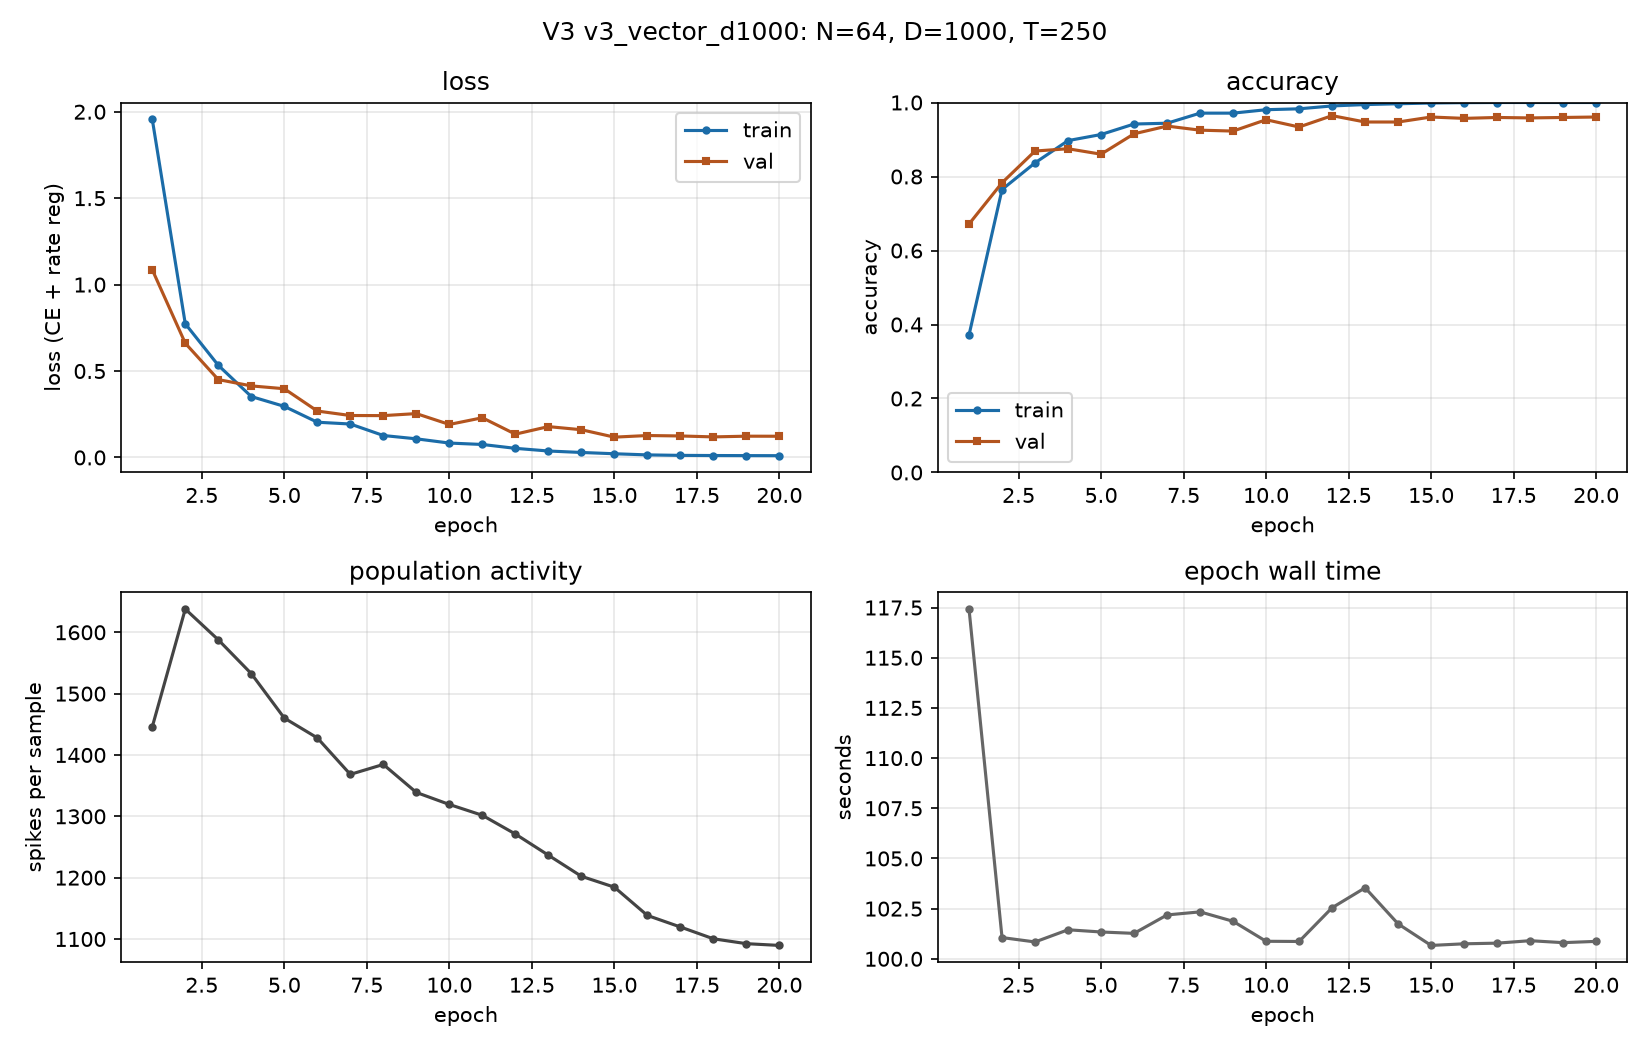

In [11]:
hist = variant.history_rows()
print(f"{'epoch':>5} {'loss':>8} {'train_acc':>10} {'val_loss':>9} {'val_acc':>8} "
      f"{'rate_Hz':>8} {'spikes/smp':>11} {'sec':>7}")
for h in hist[:: max(1, len(hist) // 25)] + [hist[-1]]:
    print(f"{h['epoch']:>5} {h['loss']:>8.4f} {h['accuracy']:>10.4f} "
          f"{h.get('val_loss', float('nan')):>9.4f} {h.get('val_accuracy', float('nan')):>8.4f} "
          f"{h.get('train_rate_mean_hz', float('nan')):>8.1f} "
          f"{h['spikes_per_sample']:>11.0f} {h['time_s']:>7.1f}")
display(Image(filename=str(variant.figures["training"])))

## 10. Save checkpoint

Configuration, model checkpoint, training/validation metrics, the per-epoch
history and (after §11) the test predictions are all written under `V3/`.

In [12]:
import torch as _torch

ck = _torch.load(variant.checkpoint_path, map_location="cpu", weights_only=False)
print(f"checkpoint  : {variant.checkpoint_path}")
print(f"schema      : {ck['schema']}")
print(f"keys        : {sorted(ck.keys())}")
print(f"parameters  : {variant.model.n_parameters():,}")
print(f"best-val epoch: {ck['best_epoch']}  (val acc {ck['best_val_accuracy']:.4f})")
print(f"results dir : {variant.dirs['results']}")
for p in sorted(variant.dirs["results"].iterdir()):
    print(f"   {p.name}")

checkpoint  : C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\V3\checkpoints\v3_vector_d1000.pt
schema      : v3_checkpoint/v1
keys        : ['best_epoch', 'best_val_accuracy', 'best_val_state_dict', 'config', 'fit_metrics', 'schema', 'state_dict', 'val_metrics']
parameters  : 2,025,440
best-val epoch: 12  (val acc 0.9645)
results dir : C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\V3\results\v3_vector_d1000
   config.json
   history.csv
   notebook_summary.json
   test_confusion.json
   test_metrics.json
   test_predictions.npz
   train_metrics.json


## 11. Test

The official SHD test set.  Parameters are frozen, gradients are disabled, and
**every** test sample is evaluated.  Nothing here is estimated.

In [13]:
test = test_variant(variant, which="final", show_progress=True)
print()
print(f"correct : {test['test_correct']}")
print(f"total   : {test['test_total']}")
print(f"accuracy: {test['test_accuracy'] * 100:.2f}%")
print(f"errors  : {test['test_errors']}")
print()
print(f"test firing rate: mean {test['rate_mean_hz']:.1f} Hz / max {test['rate_max_hz']:.1f} Hz")
if test["max_memory_allocated_mb"]:
    print(f"peak CUDA memory during the test pass: {test['max_memory_allocated_mb']:.0f} MiB")

[V3] v3_vector_d1000: official TEST 2264 samples (speakers [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


[V3] v3_vector_d1000 (final) TEST: correct 1807 / total 2264 = 79.81%

correct : 1807
total   : 2264
accuracy: 79.81%
errors  : 457

test firing rate: mean 17.1 Hz / max 29.2 Hz
peak CUDA memory during the test pass: 1283 MiB


## 12. Test visualisations

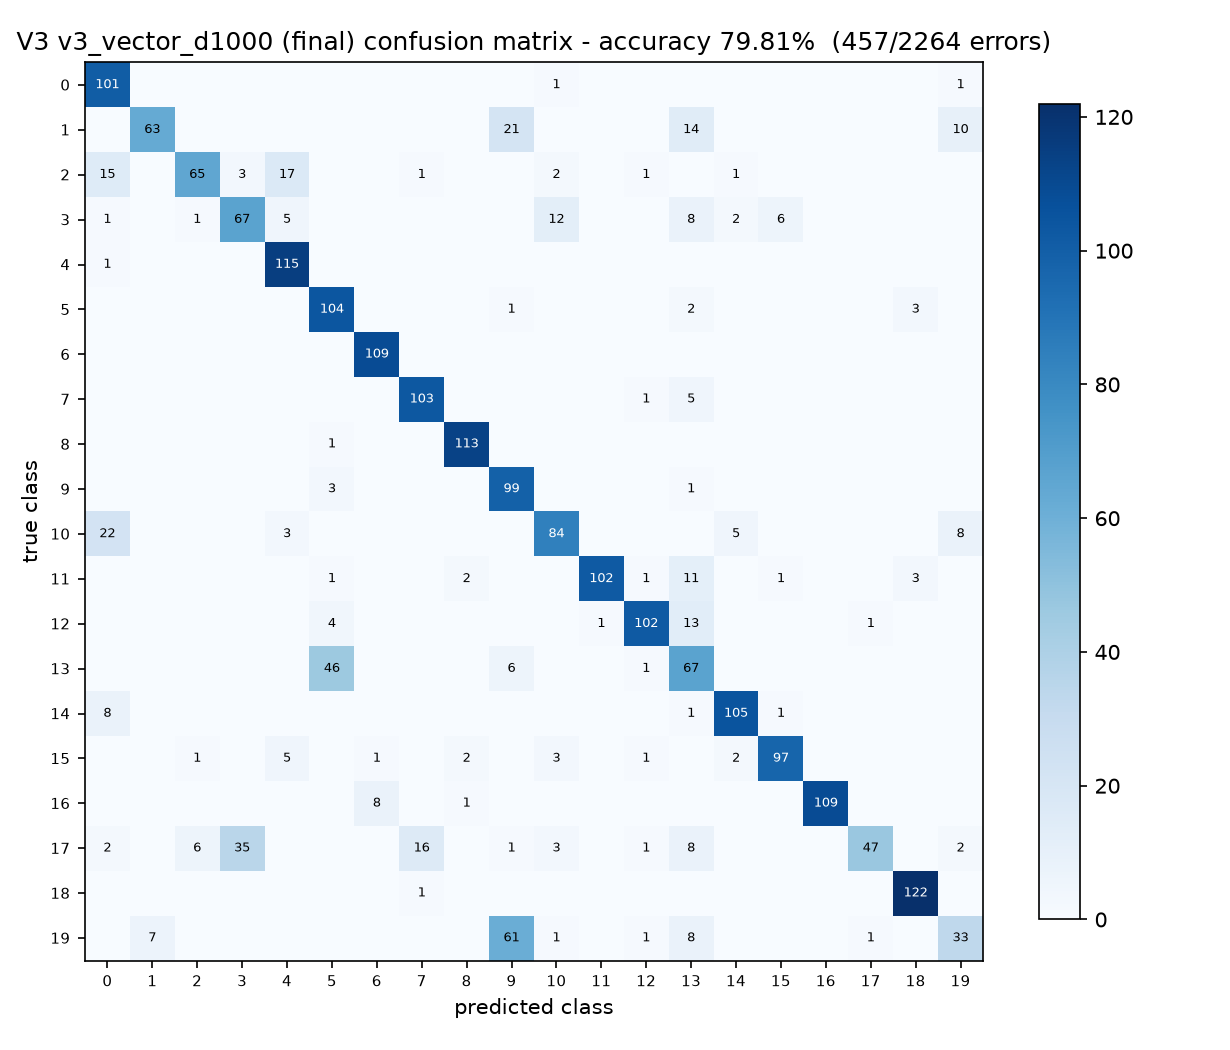

In [14]:
display(Image(filename=str(variant.figures["confusion"])))

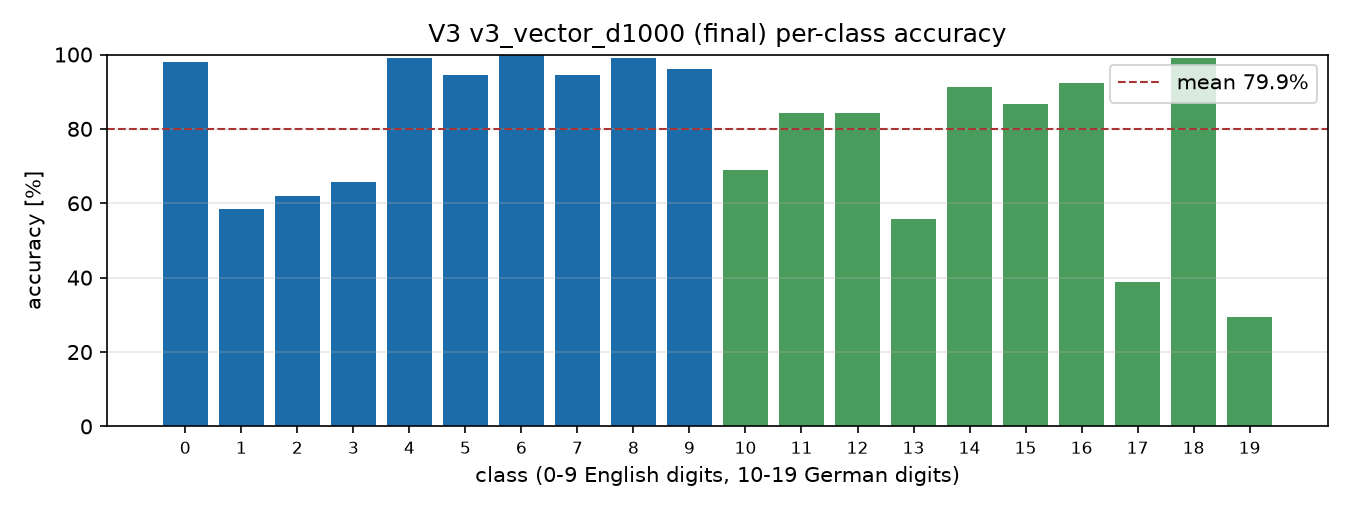

In [15]:
display(Image(filename=str(variant.figures["per_class"])))

per-class accuracy: min 29.5%, median 89.0%, max 100.0%, classes below 10%: 0
English digits 0-9 : 86.74%
German  digits 10-19: 73.11%


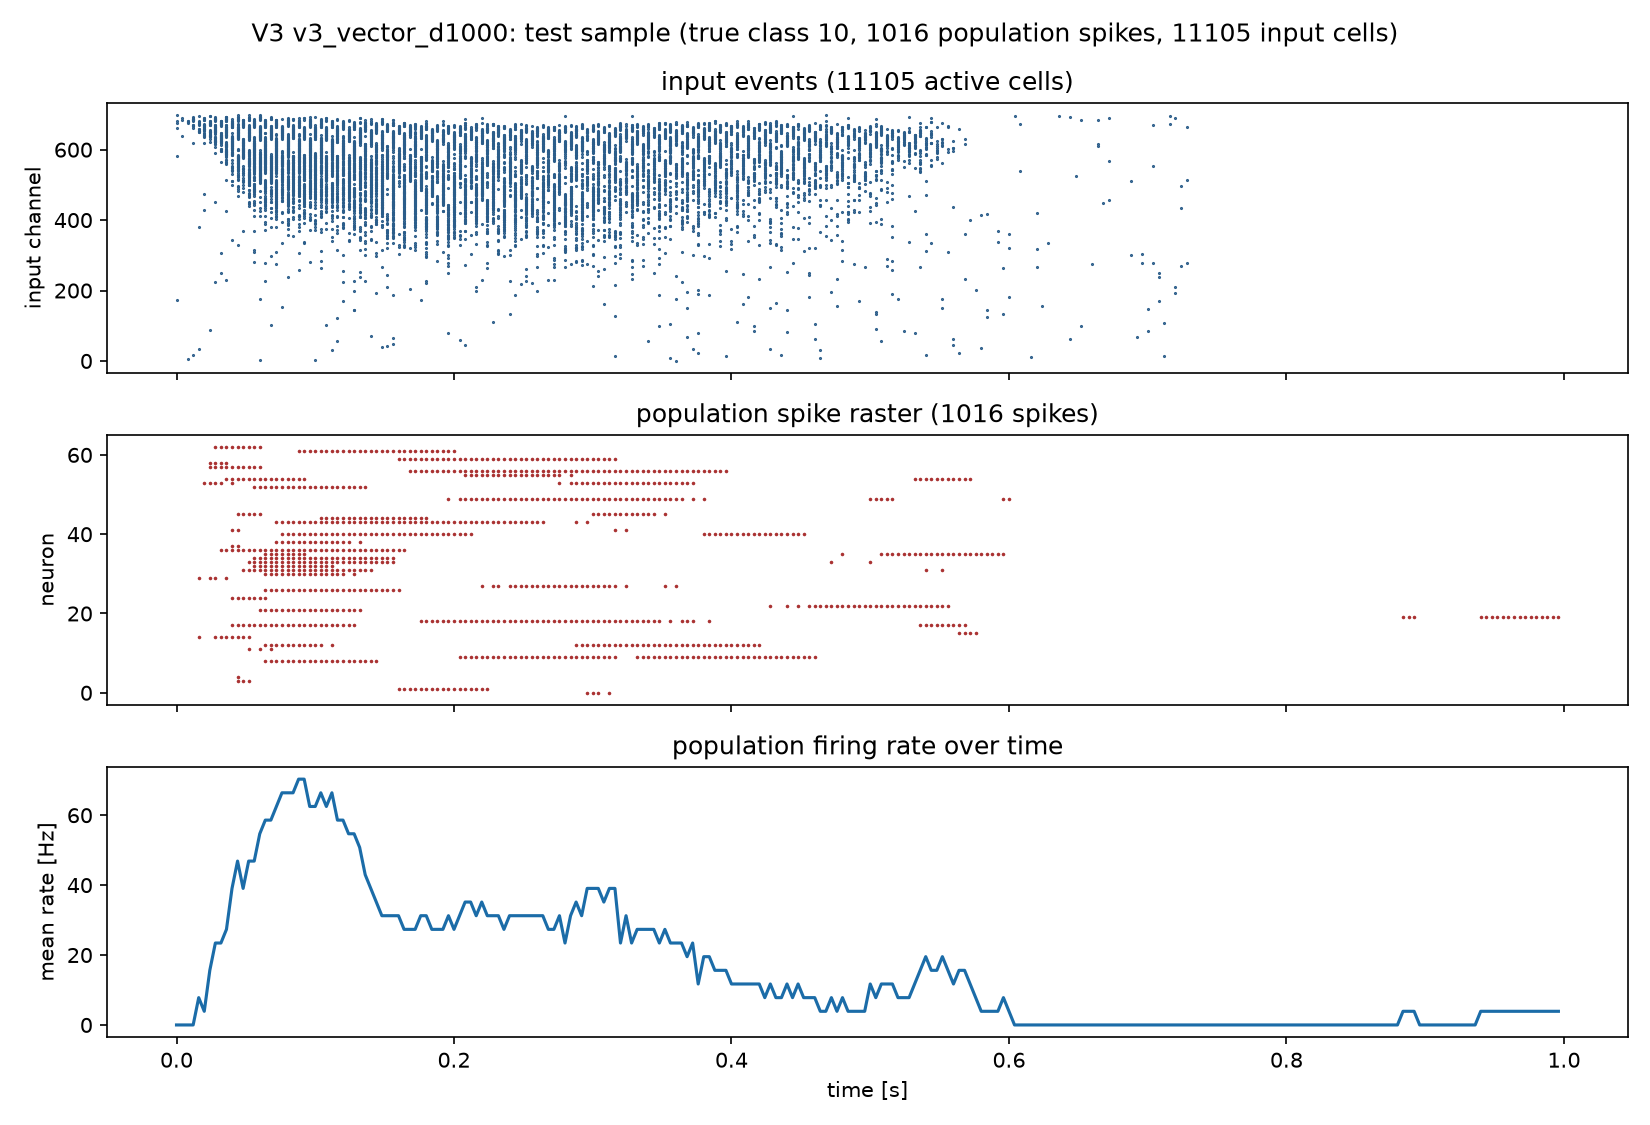

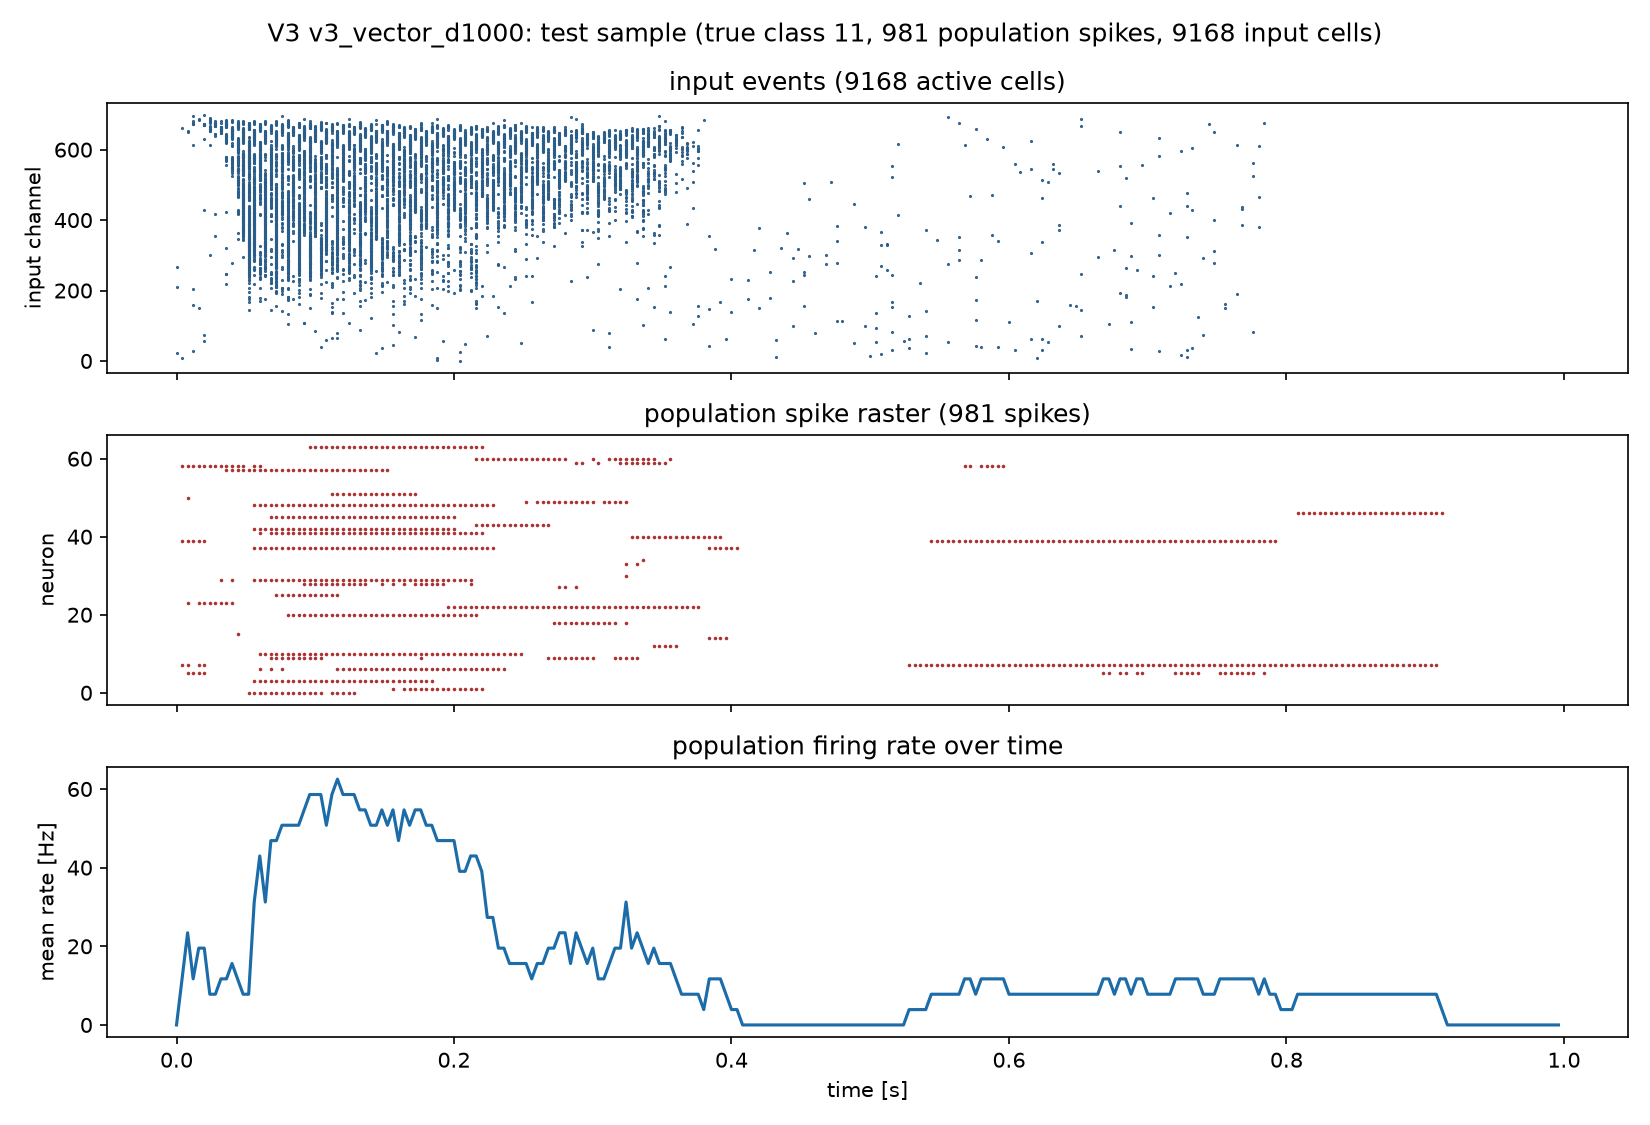

In [16]:
pc = test["per_class_accuracy"]
print(f"per-class accuracy: min {pc.min() * 100:.1f}%, median {np.median(pc) * 100:.1f}%, "
      f"max {pc.max() * 100:.1f}%, classes below 10%: {int((pc < 0.1).sum())}")
print(f"English digits 0-9 : {pc[:10].mean() * 100:.2f}%")
print(f"German  digits 10-19: {pc[10:].mean() * 100:.2f}%")
for p in variant.figures.get("activity", [])[:2]:
    display(Image(filename=str(p)))

## 13. Scalar baseline

The same $N$ neurons, the same data, the same training procedure, the same
classifier — but each neuron's state is a **scalar** ($D=1$).  This is the
reference point: it isolates the effect of the state being $D$-dimensional.

In [17]:
scalar_cfg = cfg.with_overrides(
    state_dim=1,
    mix_rank=1,
    tag=cfg.tag.replace("_d1000", "") + "_scalar_d1",
)
scalar_cfg.validate()
print(f"scalar baseline: N={scalar_cfg.n_neurons}, D={scalar_cfg.state_dim}, "
      f"T={scalar_cfg.n_bins}, {cfg.epochs} epochs, lr {scalar_cfg.learning_rate:g}")

scalar = train_variant(scalar_cfg, device=device, show_progress=True)
scalar_test = test_variant(scalar, which="final", show_progress=True)
print()
print(f"correct : {scalar_test['test_correct']}")
print(f"total   : {scalar_test['test_total']}")
print(f"accuracy: {scalar_test['test_accuracy'] * 100:.2f}%")

scalar baseline: N=64, D=1, T=250, 20 epochs, lr 0.001
[V3] v3_vector_scalar_d1: FIT 7340 / VAL 816 samples (official test set not touched)
[V3] threshold calibrated; parameters = 6,335


epoch   1/20  loss 2.7977  acc 0.1135  val_acc 0.1556  lr 9.99e-04  48.8s


epoch   2/20  loss 2.4419  acc 0.2044  val_acc 0.2181  lr 9.87e-04  33.4s


epoch   3/20  loss 2.2656  acc 0.2533  val_acc 0.2990  lr 9.63e-04  32.9s


epoch   4/20  loss 2.1062  acc 0.3117  val_acc 0.3272  lr 9.26e-04  33.7s


...

epoch  18/20  loss 1.6130  acc 0.4646  val_acc 0.4694  lr 2.60e-05  33.1s


epoch  19/20  loss 1.6053  acc 0.4636  val_acc 0.4718  lr 6.54e-06  33.2s


epoch  20/20  loss 1.6015  acc 0.4687  val_acc 0.4804  lr 0.00e+00  32.9s


[V3] v3_vector_scalar_d1 trained: 20 epochs in 714.9s  (FIT acc 0.4689, VAL acc 0.4804)
[V3] v3_vector_scalar_d1: official TEST 2264 samples (speakers [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


[V3] v3_vector_scalar_d1 (final) TEST: correct 982 / total 2264 = 43.37%

correct : 982
total   : 2264
accuracy: 43.37%


## 14. Final comparison

In [18]:
import pandas as pd

table = pd.DataFrame([
    dict(model=f"vector  (D={cfg.state_dim})",
         N=cfg.n_neurons, D=cfg.state_dim, params=variant.model.n_parameters(),
         fit_acc=round(variant.fit_metrics["accuracy"], 4),
         val_acc=round(variant.val_metrics["accuracy"], 4),
         test_correct=test["test_correct"], test_total=test["test_total"],
         test_acc=round(test["test_accuracy"], 4),
         train_s=round(variant.result.total_seconds, 1)),
    dict(model=f"scalar  (D={scalar_cfg.state_dim})",
         N=scalar_cfg.n_neurons, D=scalar_cfg.state_dim, params=scalar.model.n_parameters(),
         fit_acc=round(scalar.fit_metrics["accuracy"], 4),
         val_acc=round(scalar.val_metrics["accuracy"], 4),
         test_correct=scalar_test["test_correct"], test_total=scalar_test["test_total"],
         test_acc=round(scalar_test["test_accuracy"], 4),
         train_s=round(scalar.result.total_seconds, 1)),
])
display(table)

delta = test["test_accuracy"] - scalar_test["test_accuracy"]
print(f"vector - scalar = {delta * 100:+.2f} percentage points")

,model,N,D,params,fit_acc,val_acc,test_correct,test_total,test_acc,train_s
0,vector (D=1000),64,1000,2025440,1.0000,0.9608,1807,2264,0.7981,2117.1
1,scalar (D=1),64,1,6335,0.4689,0.4804,982,2264,0.4337,714.9


vector - scalar = +36.44 percentage points


## 15. Results / notes

The primary outcome is the number printed in §11: the number of correctly
classified samples of the official SHD test set (2264 samples) by the population
of genuine $D=1000$ vector-valued neurons.  `V3/README.md` holds the full
documentation and `V3/TODO.md` the deliberately-unimplemented future work.

In [19]:
summary = {
    "config": cfg.to_dict(),
    "quick_mode": QUICK,
    "vector": {
        "n_parameters": variant.model.n_parameters(),
        "parameter_groups": variant.model.param_groups(),
        "fit_accuracy": variant.fit_metrics["accuracy"],
        "val_accuracy": variant.val_metrics["accuracy"],
        "test_correct": test["test_correct"],
        "test_total": test["test_total"],
        "test_accuracy": test["test_accuracy"],
        "train_seconds": variant.result.total_seconds,
        "dtypes": variant.result.dtypes,
        "rate_mean_hz": variant.fit_metrics["rate_mean_hz"],
        "rate_max_hz": variant.fit_metrics["rate_max_hz"],
    },
    "scalar": {
        "n_parameters": scalar.model.n_parameters(),
        "fit_accuracy": scalar.fit_metrics["accuracy"],
        "val_accuracy": scalar.val_metrics["accuracy"],
        "test_correct": scalar_test["test_correct"],
        "test_total": scalar_test["test_total"],
        "test_accuracy": scalar_test["test_accuracy"],
        "train_seconds": scalar.result.total_seconds,
        "rate_mean_hz": scalar.fit_metrics["rate_mean_hz"],
    },
    "history_vector": variant.history_rows(),
    "history_scalar": scalar.history_rows(),
    "surrogate": "fast-sigmoid gamma*u/(1+beta*|u|), beta=%.1f gamma=%.1f"
                 % (cfg.surrogate_beta, cfg.surrogate_gamma),
}
out = variant_dirs(cfg)["results"] / ("notebook_summary_quick.json" if QUICK else "notebook_summary.json")
save_json(summary, out)
print(f"wrote {out}")
print()
print("=" * 62)
v, s = summary["vector"], summary["scalar"]
print(f"VECTOR  D={cfg.state_dim:<5} N={cfg.n_neurons:<4} {v['n_parameters']:>10,} params   "
      f"test {v['test_correct']:5d}/{v['test_total']} = {v['test_accuracy'] * 100:6.2f}%")
print(f"SCALAR  D={scalar_cfg.state_dim:<5} N={scalar_cfg.n_neurons:<4} "
      f"{s['n_parameters']:>10,} params   "
      f"test {s['test_correct']:5d}/{s['test_total']} = {s['test_accuracy'] * 100:6.2f}%")
print("=" * 62)

wrote C:\Users\Administrator\Desktop\compneuro\neuron_as_vector\V3\results\v3_vector_d1000\notebook_summary.json

VECTOR  D=1000  N=64    2,025,440 params   test  1807/2264 =  79.81%
SCALAR  D=1     N=64        6,335 params   test   982/2264 =  43.37%


---

### Honest notes / limitations

* **Single seed.**  One configuration, one seed (`seed` in the YAML).  There is
  no error bar on any number here; multi-seed replication is in `TODO.md`.
* **Validation is not speaker-independent.**  `VAL` is a stratified random 10%
  of the official *training* file, so it shares speakers with `FIT`.  The
  published SHD train/test gap is dominated by speaker shift (the official test
  set contains speakers 4 and 5, which never appear in the training file), so
  `VAL` is optimistic and is used only for monitoring / best-checkpoint
  selection.  The **test** number is the honest, comparable one.
* **The window truncates the tail.**  `T x bin_ms = 1000 ms` covers 96.6% of the
  training utterances and 99.0% of the test utterances; later events are dropped.
* **No data augmentation.**  Published competitive SHD numbers typically use
  event dropout / time-shift augmentation; none is used here.
* **The state magnitude is modest** (order 0.1), because SHD's binned input is
  very sparse; the neurons therefore operate in the gently-nonlinear part of
  `tanh` rather than deep in saturation.  This is measured in §5, not assumed.